In [43]:
from pymongo import MongoClient

In [44]:
# MongoDB 로컬 서버 연결
# mongodb 접속 포트 : 27017
client = MongoClient("mongodb://localhost:27017/")

# MongoDB 데이터베이스 생성
db = client["testdb"]

# 컬렉션 생성 (>>RDBMS table)
collection = db["students"]

# 데이터 삽입
collection.insert_one({"name": "홍길동", "age": 23, "major": "컴퓨터공학"})

InsertOneResult(ObjectId('6a1cf973dac8b852e3754a6d'), acknowledged=True)

In [45]:
# 데이터 조회
for doc in collection.find():
    print(doc)

{'_id': ObjectId('6a1ce0a2dac8b852e3754a3b'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}
{'_id': ObjectId('6a1ce9eadac8b852e3754a3e'), 'name': '박민수', 'age': 29, 'major': '영문학'}
{'_id': ObjectId('6a1ce9eadac8b852e3754a3f'), 'name': '김소희', 'age': 31, 'major': '전자공학'}
{'_id': ObjectId('6a1ce9eadac8b852e3754a40'), 'name': '우희진', 'age': 36, 'major': '영문학'}
{'_id': ObjectId('6a1ce9eadac8b852e3754a41'), 'name': '여홍철', 'age': 28, 'major': '체육학'}
{'_id': ObjectId('6a1cf782dac8b852e3754a53'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}
{'_id': ObjectId('6a1cf785dac8b852e3754a56'), 'name': '박민수', 'age': 29, 'major': '영문학'}
{'_id': ObjectId('6a1cf785dac8b852e3754a57'), 'name': '김소희', 'age': 31, 'major': '전자공학'}
{'_id': ObjectId('6a1cf785dac8b852e3754a58'), 'name': '우희진', 'age': 36, 'major': '영문학'}
{'_id': ObjectId('6a1cf785dac8b852e3754a59'), 'name': '여홍철', 'age': 28, 'major': '체육학'}
{'_id': ObjectId('6a1cf973dac8b852e3754a6d'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}


## 기본 CRUD 실습
: CRUD는 Create, Read, Update, Delete의 약자

In [116]:
# DB 생성 및 연결
# MongoDB 로컬 서버 연결
# mongodb 접속 포트 : 27017
client = MongoClient("mongodb://localhost:27017/")
# MongoDB 데이터베이스 생성
db = client["testdb"]
# 컬렉션 생성 (>>RDBMS table)
collection = db["students"]

# Create
collection.insert_many([
    {"name": "홍길동", "age": 23, "major": "컴퓨터공학"},
    {"name": "김철수", "age": 21, "major": "물리학"},
    {"name": "박민수", "age": 29, "major": "영문학"},
    {"name": "김소희", "age": 31, "major": "전자공학"},
    {"name": "우희진", "age": 36, "major": "영문학"},
    {"name": "여홍철", "age": 28, "major": "체육학"},
    {"name": "이영희", "age": 22, "major": "수학"}, 
])

InsertManyResult([ObjectId('6a1d137edac8b852e3754adc'), ObjectId('6a1d137edac8b852e3754add'), ObjectId('6a1d137edac8b852e3754ade'), ObjectId('6a1d137edac8b852e3754adf'), ObjectId('6a1d137edac8b852e3754ae0'), ObjectId('6a1d137edac8b852e3754ae1'), ObjectId('6a1d137edac8b852e3754ae2')], acknowledged=True)

In [117]:
# Update
collection.update_one({"name": "김철수"}, {"$set": {"age": 45}})

UpdateResult({'n': 1, 'nModified': 1, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [118]:
# Delete
collection.delete_one({"name": "이영희"})
collection.delete_one({"name": "김철수"})

DeleteResult({'n': 1, 'ok': 1.0}, acknowledged=True)

In [119]:
# Read
for student in collection.find():
    print(student)

client.close()

{'_id': ObjectId('6a1d137edac8b852e3754adc'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}
{'_id': ObjectId('6a1d137edac8b852e3754ade'), 'name': '박민수', 'age': 29, 'major': '영문학'}
{'_id': ObjectId('6a1d137edac8b852e3754adf'), 'name': '김소희', 'age': 31, 'major': '전자공학'}
{'_id': ObjectId('6a1d137edac8b852e3754ae0'), 'name': '우희진', 'age': 36, 'major': '영문학'}
{'_id': ObjectId('6a1d137edac8b852e3754ae1'), 'name': '여홍철', 'age': 28, 'major': '체육학'}


## csv 파일 --> MongoDB 저장

In [120]:
import pandas as pd

In [121]:
# csv 파일 읽어오기
df = pd.read_csv('./data/Subjects.csv')
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


In [122]:
# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["students_csv"]

# DataFrame을 딕셔너리 리스트로 변환 후 MongoDB에 저장
# DataFrame을 [{},{},{},......] 형태의 리스트로 변환
collection.insert_many(df.to_dict("records"))
print("csv 데이터가 mongodb에 저장되었습니다.")

# Read
for students_csv in collection.find():
    print(students_csv)
    
client.close()

csv 데이터가 mongodb에 저장되었습니다.
{'_id': ObjectId('6a1cfe65dac8b852e3754aa4'), 'class': 1, 'name': 'aaa', 'kor': 67, 'eng': 87, 'math': 90, 'science': 98}
{'_id': ObjectId('6a1cfe65dac8b852e3754aa5'), 'class': 1, 'name': 'bbb', 'kor': 45, 'eng': 45, 'math': 56, 'science': 98}
{'_id': ObjectId('6a1cfe65dac8b852e3754aa6'), 'class': 1, 'name': 'ccc', 'kor': 95, 'eng': 59, 'math': 96, 'science': 88}
{'_id': ObjectId('6a1cfe65dac8b852e3754aa7'), 'class': 1, 'name': 'ddd', 'kor': 65, 'eng': 94, 'math': 89, 'science': 98}
{'_id': ObjectId('6a1cfe65dac8b852e3754aa8'), 'class': 1, 'name': 'eee', 'kor': 45, 'eng': 65, 'math': 78, 'science': 98}
{'_id': ObjectId('6a1cfe65dac8b852e3754aa9'), 'class': 1, 'name': 'fff', 'kor': 78, 'eng': 76, 'math': 98, 'science': 89}
{'_id': ObjectId('6a1cfe65dac8b852e3754aaa'), 'class': 2, 'name': 'ggg', 'kor': 87, 'eng': 67, 'math': 65, 'science': 56}
{'_id': ObjectId('6a1cfe65dac8b852e3754aab'), 'class': 2, 'name': 'hhh', 'kor': 89, 'eng': 98, 'math': 78, 'science': 7

## 1) 이미지 --> MongoDB에 저장

In [123]:
import base64
from io import BytesIO

In [124]:
with open("./data/dog.jpg", "rb") as img_file:
    encoded = base64.b64encode(img_file.read()).decode("utf-8")

# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["images"]

# MongoDB에 저장
collection.insert_one({"filename": "dog.jpg", "data": encoded})

InsertOneResult(ObjectId('6a1d1390dac8b852e3754af1'), acknowledged=True)

## 이미지 저장 : 이미지 --> base64 --> 바이너리로 변환(encode) --> 저장
## 이미지 불러오기 : base64 --> 바이너리 --> 이미지 객체로 변환(decode)하여 출력

## 2) MongoDB Image --> python 출력

MongoDB에서 이미지를 읽어왔습니다.


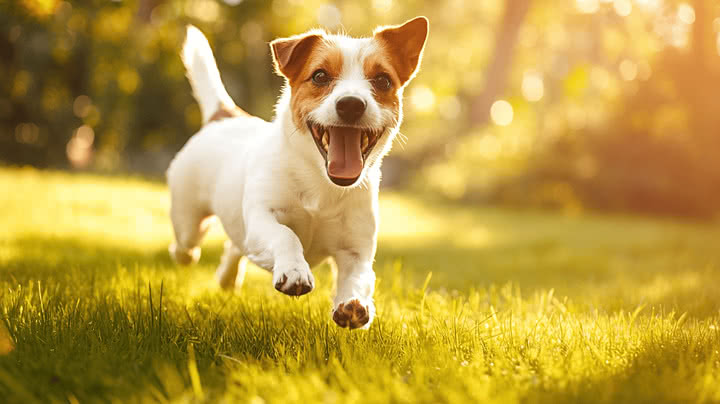

In [125]:
from PIL import Image

# MongoDB에서 이미지 데이터 가져오기
document = collection.find_one({"filename": "dog.jpg"})
if document:
    img_data = document["data"]
    # base64 --> 바이너리로 변환
    img_binary = base64.b64decode(img_data)
    # 메모리에서 바로 이미지 객체 생성
    img = Image.open(BytesIO(img_binary))
    print("MongoDB에서 이미지를 읽어왔습니다.")
    display(img)
else:
    print("dog.jpg 이미지를 찾을 수 없습니다.")

# 퀴즈1) MongoDB student_csv 컬렉션에 있는 데이터를 읽어와 영어점수 막대 그래프를 출력하기

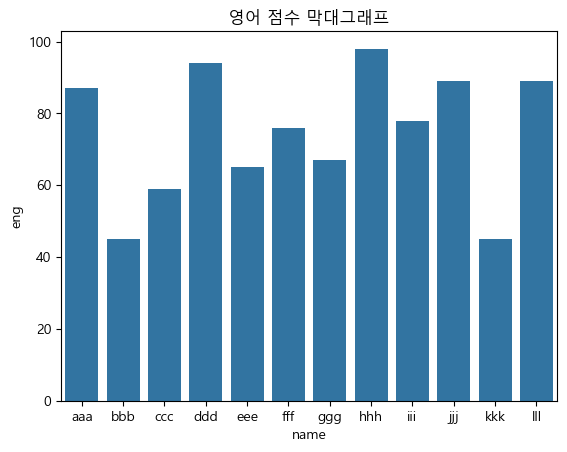

In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from pymongo import MongoClient

# 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 음수 값 표시 문제 방지
plt.rcParams['axes.unicode_minus'] = False

# DB 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["students_csv"]

# MongoDB --> DataFrame
data = pd.DataFrame(list(collection.find({}, {"_id": 0})))
eng = data["eng"]

# 시각화
sns.barplot(data=data, x="name", y="eng")
plt.title('영어 점수 막대그래프')
plt.show()

# DB 종료
client.close()

## 퀴즈2) 나이 분포 히스토그램, 전공별 학생 수 막대그래프, 전공별 나이 분포 박스플롯

  name  age  major
0  홍길동   23  컴퓨터공학
1  박민수   29    영문학
2  김소희   31   전자공학
3  우희진   36    영문학
4  여홍철   28    체육학


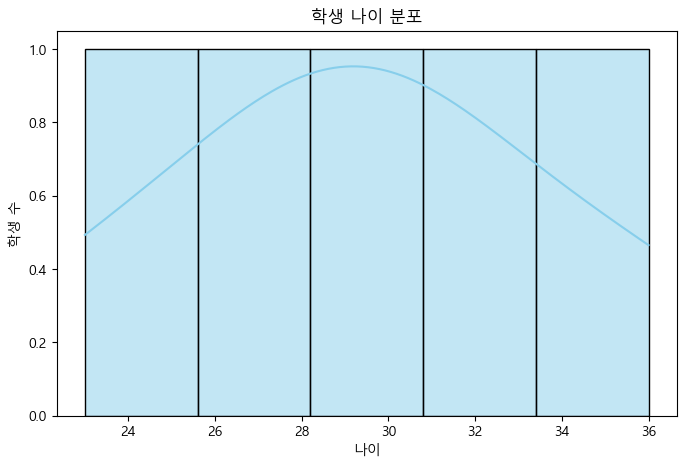

C:\Users\human3_01\AppData\Local\Temp\ipykernel_2116\2275022116.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="major", data=df, palette="pastel")


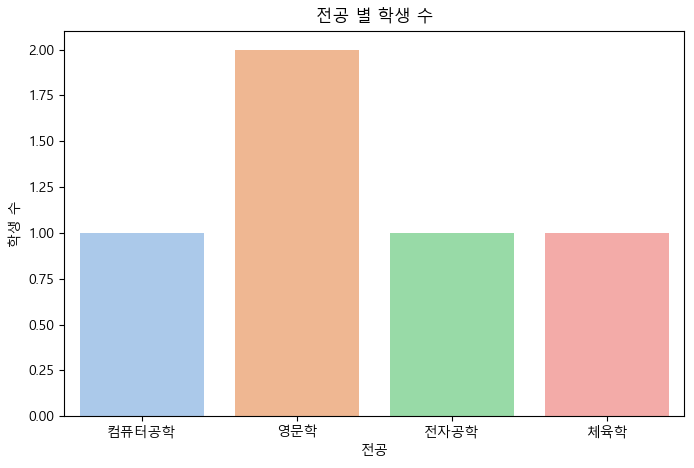

C:\Users\human3_01\AppData\Local\Temp\ipykernel_2116\2275022116.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="major", y="age", data=df, palette="Set2")


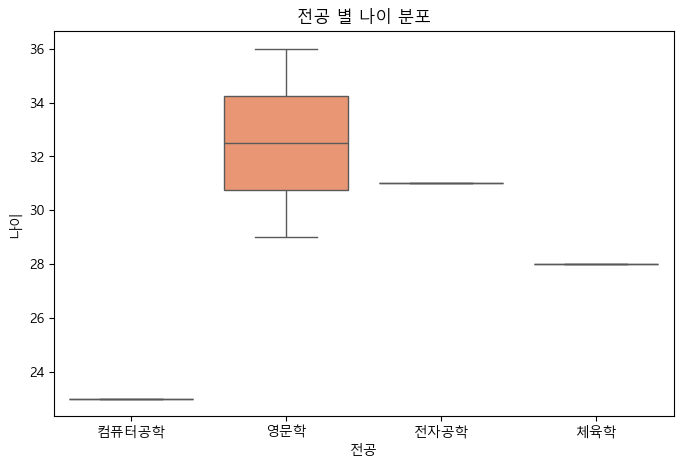

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from pymongo import MongoClient

# 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 음수 값 표시 문제 방지
plt.rcParams['axes.unicode_minus'] = False

# DB 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["students"]

cursor = collection.find({})
df = pd.DataFrame(list(cursor))
client.close()

# _id 컬럼 제거
if "_id" in df.columns:
    df = df.drop("_id", axis=1)

print(df)

# -----------------------------------
#   나이 분포 히스토그램
# -----------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=5, kde=True, color='skyblue')
plt.title('학생 나이 분포')
plt.xlabel('나이')
plt.ylabel('학생 수')
plt.show()

# -----------------------------------
#   전공별 학생 수 막대그래프
# -----------------------------------
plt.figure(figsize=(8,5))
sns.countplot(x="major", data=df, palette="pastel")
plt.title('전공 별 학생 수')
plt.xlabel('전공')
plt.ylabel('학생 수')
plt.show()

# -----------------------------------
#   전공별 나이 분포 박스플롯
# -----------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="major", y="age", data=df, palette="Set2")
plt.title('전공 별 나이 분포')
plt.xlabel('전공')
plt.ylabel('나이')
plt.show()

## Tkinter 실행(파이썬에서 GUI를 그려주는 라이브러리)

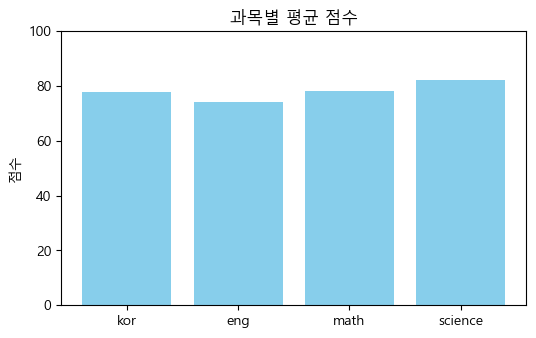

In [134]:
import tkinter as tk
from tkinter import ttk
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib import font_manager, rc

# 한글 폰트 설정 (Windows용)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# MongoDB 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testdb"]
collection = db["students_csv"]

# 데이터 불러오기
data = list(collection.find({}, {"_id": 0}))
df = pd.DataFrame(data)

# Tkinter 메인 윈도우
root = tk.Tk()
root.title("학생 점수 대시보드")
root.geometry("900x700")

# === 제목 ===
title_label = tk.Label(root, text="학생 점수 대시보드", font=("Malgun Gothic", 18, "bold"))
title_label.pack(pady=10)

# === Treeview 테이블 ===
frame_table = tk.Frame(root)
frame_table.pack(pady=10)

columns = list(df.columns)
tree = ttk.Treeview(frame_table, columns=columns, show="headings", height=10)

# 컬럼 헤더 설정
for col in columns:
    tree.heading(col, text=col)
    tree.column(col, width=100, anchor="center")

# 데이터 삽입
for _, row in df.iterrows():
    tree.insert("", "end", values=list(row))

tree.pack()

# === Matplotlib 그래프 표시 ===
frame_graph = tk.Frame(root)
frame_graph.pack(pady=20)

# 과목별 평균 계산
mean_scores = df[["kor", "eng", "math", "science"]].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mean_scores.index, mean_scores.values, color="skyblue")
ax.set_title("과목별 평균 점수")
ax.set_ylabel("점수")
ax.set_ylim(0, 100)

# Tkinter에 matplotlib 그래프 추가
canvas = FigureCanvasTkAgg(fig, master=frame_graph)
canvas.draw()
canvas.get_tk_widget().pack()

# === 종료 버튼 ===
exit_button = tk.Button(root, text="닫기", command=root.destroy, font=("Malgun Gothic", 12))
exit_button.pack(pady=10)

# Tkinter 실행
root.mainloop()

In [133]:
# 파이썬과 MongoDB의 연결을 끊는다
client.close()